<a href="https://colab.research.google.com/github/Abhi55-66/Recommend-products-using-sentiment-similarity./blob/main/Recommend_products_using_sentiment_similarity_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📂 Upload Your Excel or CSV Dataset


Saving product_reviews_250_products_25000_reviews.xlsx to product_reviews_250_products_25000_reviews.xlsx

✅ Dataset Loaded Successfully!

📊 DATASET PREVIEW
   review_id   product_name                                   review  \
0          1  Apple Model 1             Battery backup is impressive   
1          2  Apple Model 1              Very slow and disappointing   
2          3  Apple Model 1  Poor camera quality and low performance   
3          4  Apple Model 1                Performance is acceptable   
4          5  Apple Model 1         Moderate performance and battery   

  sentiment  rating  
0  Positive       4  
1  Negative       1  
2  Negative       2  
3   Neutral       3  
4   Neutral       3  

📈 Total Reviews: 25000
📱 Total Products: 250

🤖 Performing Sentiment Analysis...
✅ Sentiment Analysis Completed!

⚙ Building AI Recommendation Engine...
✅ AI Recommendation System Ready!

📊 Generating Global Chart A: Top Products by Positive Sentiment...


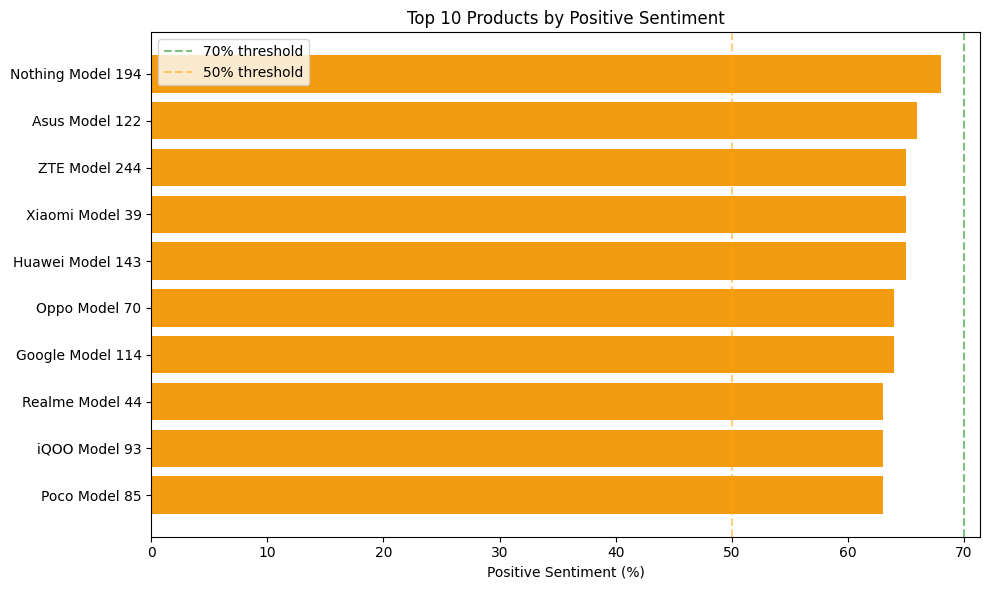


📊 Generating Global Chart B: Stacked Sentiment Mix...


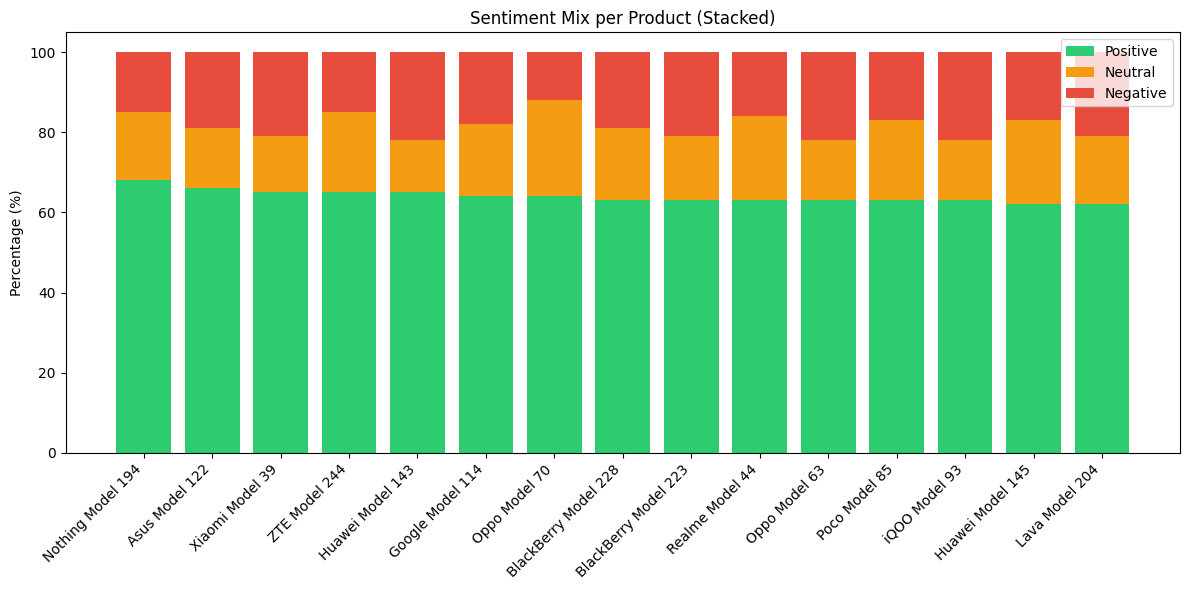


📊 Generating Global Chart C: Sentiment Heatmap...


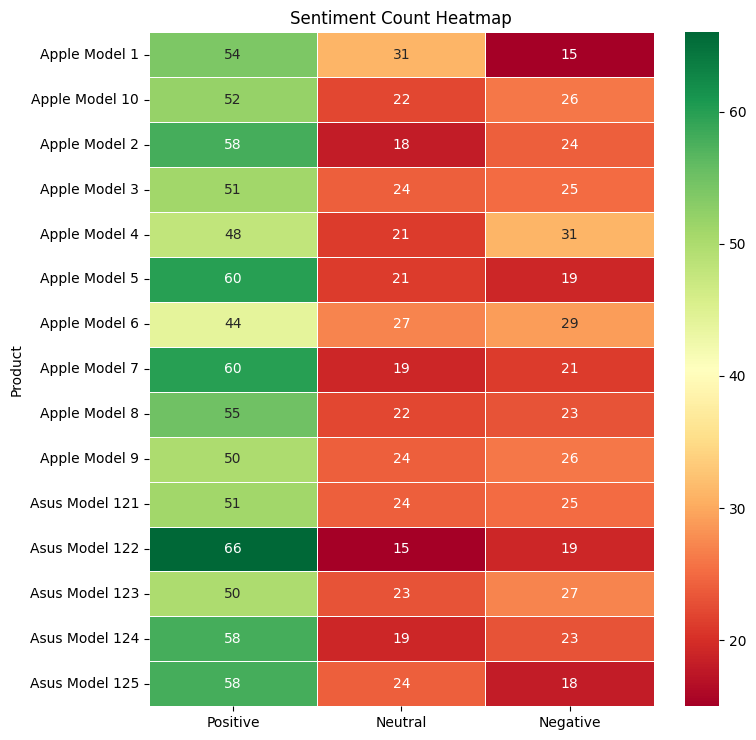


📊 Generating Global Chart D: Scatter Plot...


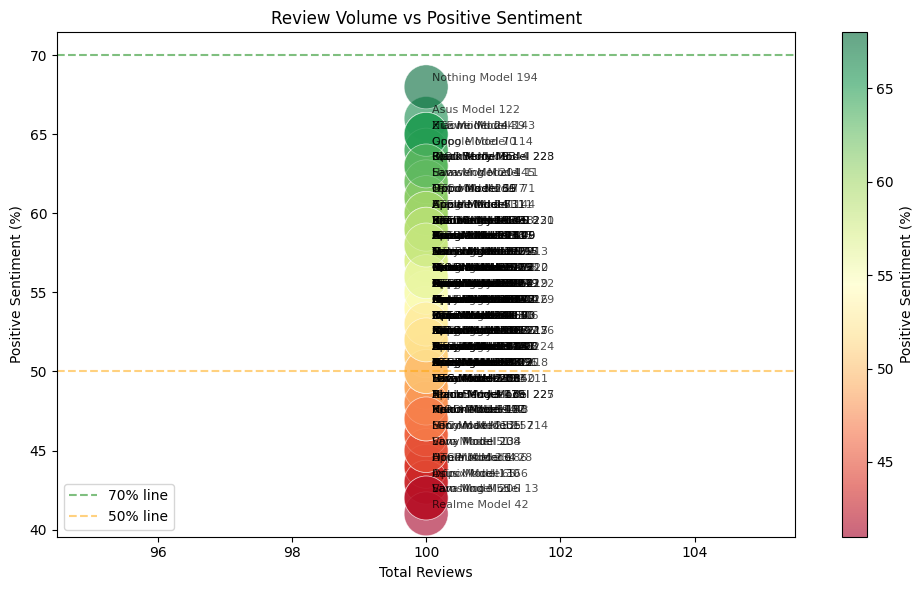


🔎 Enter Product Name (or type 'exit'): apple model 1 

❌ Product Not Found!

📌 Example Products:
['Apple Model 1', 'Apple Model 10', 'Apple Model 2', 'Apple Model 3', 'Apple Model 4', 'Apple Model 5', 'Apple Model 6', 'Apple Model 7', 'Apple Model 8', 'Apple Model 9']

🔎 Enter Product Name (or type 'exit'): Apple Model 10

🔍 PRODUCT ANALYSIS
📱 Product: Apple Model 10

📊 Sentiment Breakdown:
✅ Positive Reviews : 52
❌ Negative Reviews : 26
⚪ Neutral Reviews  : 22

📈 Positive Sentiment Score: 52.00%

🛒 PRODUCT RECOMMENDATION STATUS
------------------------------------------------------------
👍 Recommended Product

🤖 Similar Recommended Products:
------------------------------------------------------------
➡️ Lava Model 205
➡️ Honor Model 184
➡️ Honor Model 186
➡️ Xiaomi Model 34
➡️ Tecno Model 178


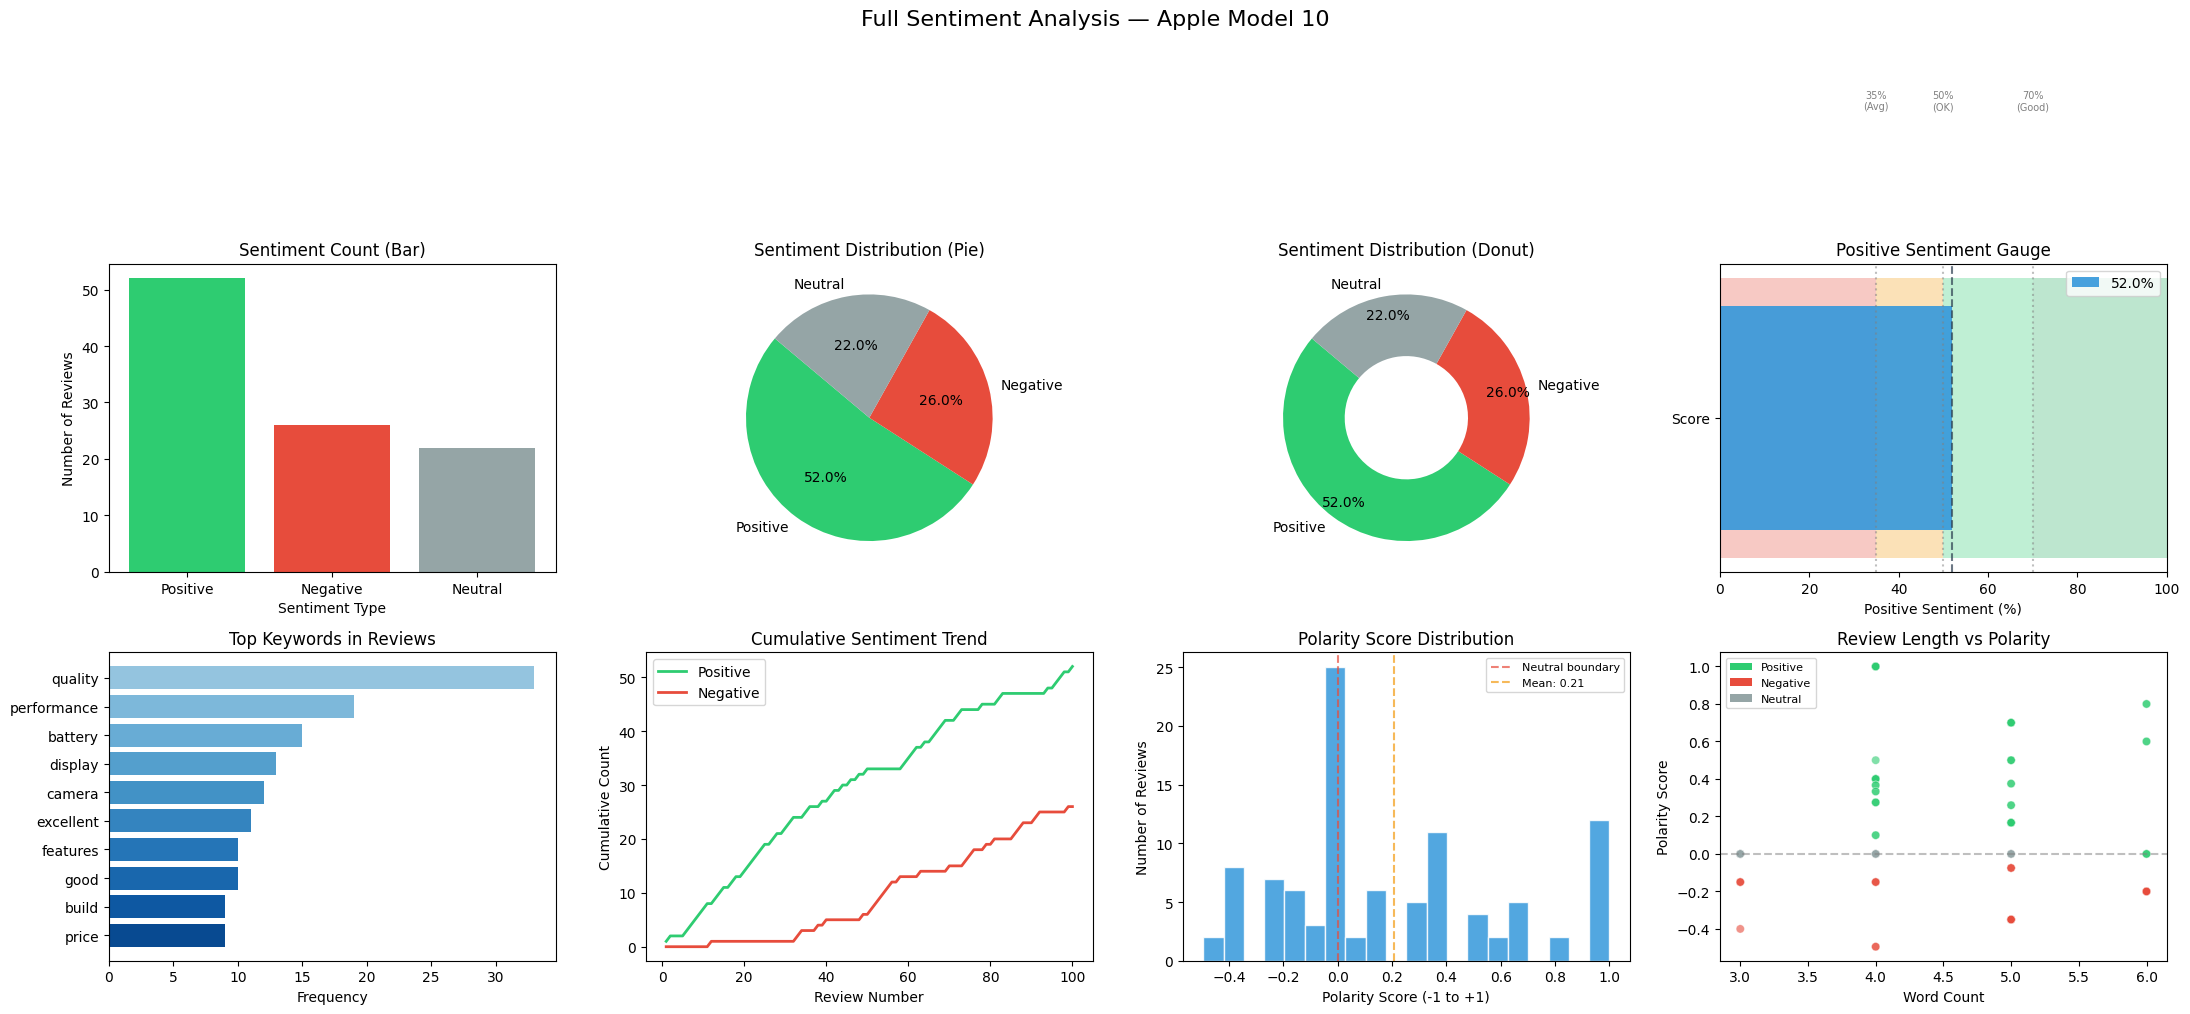


🔎 Enter Product Name (or type 'exit'): Lava Model 205

🔍 PRODUCT ANALYSIS
📱 Product: Lava Model 205

📊 Sentiment Breakdown:
✅ Positive Reviews : 50
❌ Negative Reviews : 25
⚪ Neutral Reviews  : 25

📈 Positive Sentiment Score: 50.00%

🛒 PRODUCT RECOMMENDATION STATUS
------------------------------------------------------------
👍 Recommended Product

🤖 Similar Recommended Products:
------------------------------------------------------------
➡️ Lenovo Model 154
➡️ Honor Model 184
➡️ Apple Model 10
➡️ Nokia Model 102
➡️ Honor Model 181


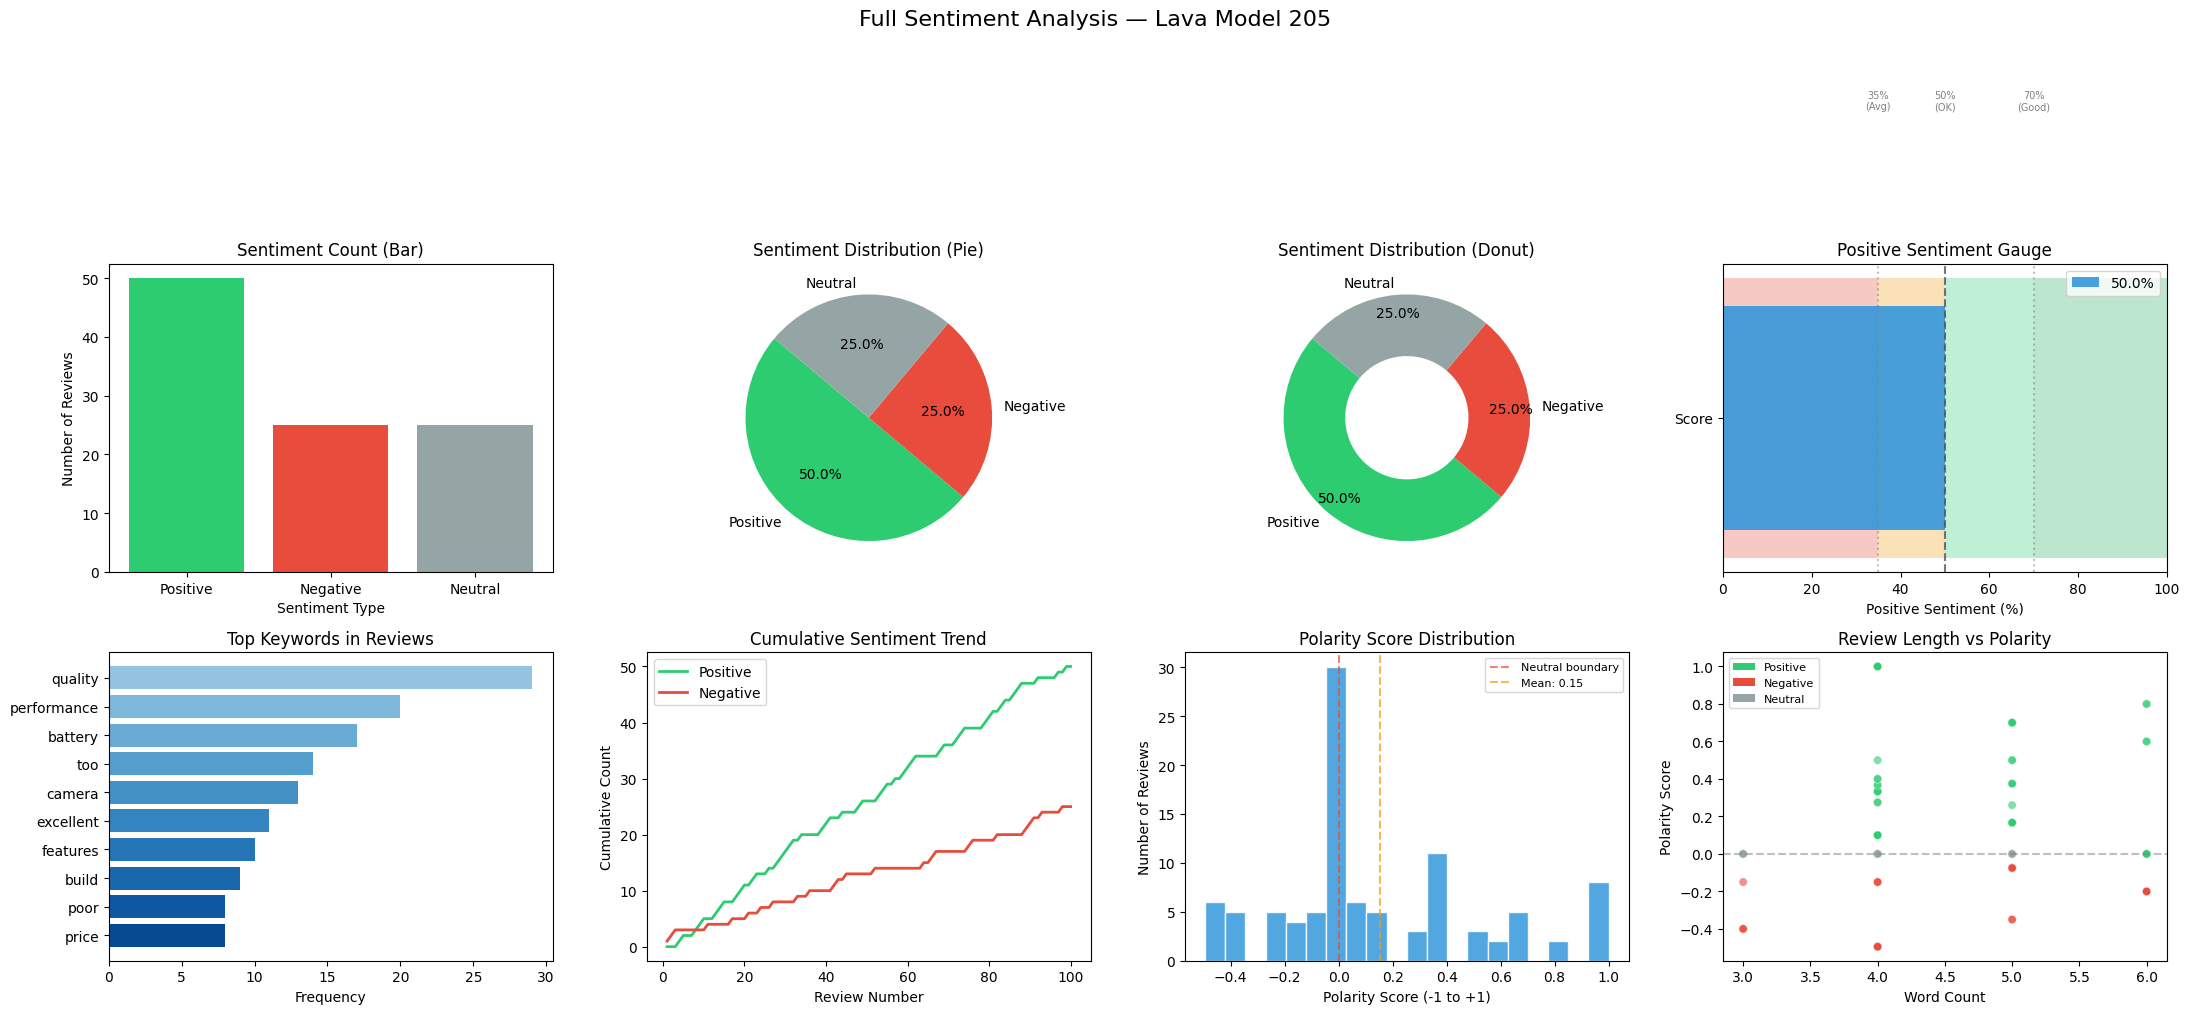

In [ ]:
# ==========================================================
# GOOGLE COLAB VERSION
# AI PRODUCT SENTIMENT ANALYSIS + PRODUCT RECOMMENDATION
# + VISUALIZATION (8 CHARTS)
# ==========================================================

# INSTALL REQUIRED LIBRARIES
!pip install textblob openpyxl matplotlib seaborn -q

# ----------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

from collections import Counter
from textblob import TextBlob

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from google.colab import files

# ----------------------------------------------------------
# STEP 1: UPLOAD DATASET
# ----------------------------------------------------------

print("📂 Upload Your Excel or CSV Dataset")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# ----------------------------------------------------------
# STEP 2: LOAD DATASET
# ----------------------------------------------------------

try:

    if file_name.endswith(".xlsx"):
        df = pd.read_excel(file_name)

    elif file_name.endswith(".csv"):
        df = pd.read_csv(file_name)

    else:
        print("❌ Unsupported File Format")
        raise Exception("Invalid File")

    print("\n✅ Dataset Loaded Successfully!")

except Exception as e:

    print("\n❌ Error Loading Dataset")
    print(e)

# ----------------------------------------------------------
# STEP 3: CHECK REQUIRED COLUMNS
# ----------------------------------------------------------

required_columns = ["product_name", "review"]

for col in required_columns:

    if col not in df.columns:

        print(f"\n❌ Missing Required Column: {col}")
        raise Exception("Dataset Error")

# ----------------------------------------------------------
# STEP 4: DATASET PREVIEW
# ----------------------------------------------------------

print("\n📊 DATASET PREVIEW")
print(df.head())

print("\n📈 Total Reviews:", len(df))
print("📱 Total Products:", df["product_name"].nunique())

# ----------------------------------------------------------
# STEP 5: SENTIMENT ANALYSIS
# ----------------------------------------------------------

print("\n🤖 Performing Sentiment Analysis...")

def get_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["sentiment"] = df["review"].apply(get_sentiment)

print("✅ Sentiment Analysis Completed!")

# ----------------------------------------------------------
# STEP 6: PRODUCT SUMMARY
# ----------------------------------------------------------

product_summary = df.groupby("product_name").agg({
    "review": " ".join,
    "sentiment": lambda x: x.value_counts().to_dict()
}).reset_index()

product_summary["product_name_lower"] = (
    product_summary["product_name"].str.lower()
)

# ----------------------------------------------------------
# STEP 7: TF-IDF AI MODEL
# ----------------------------------------------------------

print("\n⚙ Building AI Recommendation Engine...")

vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(
    product_summary["review"]
)

# ----------------------------------------------------------
# STEP 8: COSINE SIMILARITY
# ----------------------------------------------------------

similarity_matrix = cosine_similarity(tfidf_matrix)

print("✅ AI Recommendation System Ready!")

# ----------------------------------------------------------
# STEP 8.1: GLOBAL CHART A — TOP PRODUCTS BY POSITIVE %
# (Horizontal Bar Chart)
# ----------------------------------------------------------

print("\n📊 Generating Global Chart A: Top Products by Positive Sentiment...")

def chart_top_products_by_positive(top_n=10):

    rows = []

    for _, row in product_summary.iterrows():

        s     = row["sentiment"]
        pos   = s.get("Positive", 0)
        neg   = s.get("Negative", 0)
        neu   = s.get("Neutral",  0)
        total = pos + neg + neu

        if total == 0:
            continue

        rows.append({
            "product":      row["product_name"],
            "positive_pct": (pos / total) * 100
        })

    chart_df = (
        pd.DataFrame(rows)
        .sort_values("positive_pct", ascending=True)
        .tail(top_n)
    )

    colors = [
        "#2ecc71" if v >= 70 else
        "#f39c12" if v >= 50 else
        "#e74c3c"
        for v in chart_df["positive_pct"]
    ]

    plt.figure(figsize=(10, 6))

    plt.barh(
        chart_df["product"],
        chart_df["positive_pct"],
        color=colors
    )

    plt.axvline(
        x=70, color="green", linestyle="--",
        alpha=0.5, label="70% threshold"
    )
    plt.axvline(
        x=50, color="orange", linestyle="--",
        alpha=0.5, label="50% threshold"
    )

    plt.xlabel("Positive Sentiment (%)")
    plt.title(f"Top {top_n} Products by Positive Sentiment")
    plt.legend()
    plt.tight_layout()
    plt.show()

chart_top_products_by_positive()

# ----------------------------------------------------------
# STEP 8.2: GLOBAL CHART B — STACKED SENTIMENT MIX
# (Stacked Bar Chart — All Products)
# ----------------------------------------------------------

print("\n📊 Generating Global Chart B: Stacked Sentiment Mix...")

def chart_stacked_sentiment(max_products=15):

    rows = []

    for _, row in product_summary.iterrows():

        s     = row["sentiment"]
        total = sum(s.values())

        if total == 0:
            continue

        rows.append({
            "product":  row["product_name"],
            "Positive": s.get("Positive", 0) / total * 100,
            "Neutral":  s.get("Neutral",  0) / total * 100,
            "Negative": s.get("Negative", 0) / total * 100,
        })

    chart_df = (
        pd.DataFrame(rows)
        .sort_values("Positive", ascending=False)
        .head(max_products)
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    bottoms = [0] * len(chart_df)
    colors  = {
        "Positive": "#2ecc71",
        "Neutral":  "#f39c12",
        "Negative": "#e74c3c"
    }

    for sentiment_type in ["Positive", "Neutral", "Negative"]:

        ax.bar(
            chart_df["product"],
            chart_df[sentiment_type],
            bottom=bottoms,
            label=sentiment_type,
            color=colors[sentiment_type]
        )

        bottoms = [
            b + v for b, v
            in zip(bottoms, chart_df[sentiment_type])
        ]

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title("Sentiment Mix per Product (Stacked)")
    plt.legend()
    plt.tight_layout()
    plt.show()

chart_stacked_sentiment()

# ----------------------------------------------------------
# STEP 8.3: GLOBAL CHART C — SENTIMENT HEATMAP
# (Seaborn Heatmap — All Products)
# ----------------------------------------------------------

print("\n📊 Generating Global Chart C: Sentiment Heatmap...")

def chart_sentiment_heatmap(max_products=15):

    rows = []

    for _, row in product_summary.iterrows():

        s = row["sentiment"]

        rows.append({
            "Product":  row["product_name"],
            "Positive": s.get("Positive", 0),
            "Neutral":  s.get("Neutral",  0),
            "Negative": s.get("Negative", 0),
        })

    chart_df = (
        pd.DataFrame(rows)
        .set_index("Product")
        .head(max_products)
    )

    plt.figure(figsize=(8, max(4, len(chart_df) * 0.5)))

    sns.heatmap(
        chart_df,
        annot=True,
        fmt="d",
        cmap="RdYlGn",
        linewidths=0.5,
        linecolor="white"
    )

    plt.title("Sentiment Count Heatmap")
    plt.tight_layout()
    plt.show()

chart_sentiment_heatmap()

# ----------------------------------------------------------
# STEP 8.4: GLOBAL CHART D — SCATTER PLOT
# (Review Volume vs Positive Sentiment %)
# ----------------------------------------------------------

print("\n📊 Generating Global Chart D: Scatter Plot...")

def chart_scatter_volume_vs_sentiment():

    products, totals, positives = [], [], []

    for _, row in product_summary.iterrows():

        s     = row["sentiment"]
        total = sum(s.values())

        if total == 0:
            continue

        products.append(row["product_name"])
        totals.append(total)
        positives.append(s.get("Positive", 0) / total * 100)

    plt.figure(figsize=(10, 6))

    scatter = plt.scatter(
        totals,
        positives,
        s=[t * 10 for t in totals],
        alpha=0.6,
        c=positives,
        cmap="RdYlGn",
        edgecolors="white",
        linewidths=0.5
    )

    plt.colorbar(scatter, label="Positive Sentiment (%)")

    plt.axhline(
        y=70, color="green", linestyle="--",
        alpha=0.5, label="70% line"
    )
    plt.axhline(
        y=50, color="orange", linestyle="--",
        alpha=0.5, label="50% line"
    )

    for i, name in enumerate(products):
        plt.annotate(
            name,
            (totals[i], positives[i]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
            alpha=0.7
        )

    plt.xlabel("Total Reviews")
    plt.ylabel("Positive Sentiment (%)")
    plt.title("Review Volume vs Positive Sentiment")
    plt.legend()
    plt.tight_layout()
    plt.show()

chart_scatter_volume_vs_sentiment()

# ----------------------------------------------------------
# HELPER: TOP KEYWORDS EXTRACTOR
# ----------------------------------------------------------

def get_top_keywords(text, n=10):

    stopwords = {
        "the","a","an","is","it","in","on","at","to","and",
        "or","of","for","with","this","that","was","are","be",
        "as","by","its","not","but","so","from","i","we","my",
        "he","she","they","their","our","you","your","very","just"
    }

    words = [
        w.strip(".,!?\"'").lower()
        for w in str(text).split()
        if w.strip(".,!?\"'").lower() not in stopwords
        and len(w) > 2
    ]

    return Counter(words).most_common(n)

# ----------------------------------------------------------
# STEP 9: PRODUCT ANALYSIS + VISUALIZATION (8 CHARTS)
# ----------------------------------------------------------

def analyze_product(product_name, top_n=5):

    product_name = product_name.lower()

    # CHECK PRODUCT EXISTS
    if product_name not in product_summary[
        "product_name_lower"
    ].values:

        print("\n❌ Product Not Found!")

        print("\n📌 Example Products:")

        print(
            product_summary["product_name"]
            .head(10)
            .to_list()
        )

        return

    # FIND PRODUCT INDEX
    index = product_summary[
        product_summary["product_name_lower"] == product_name
    ].index[0]

    actual_name = product_summary.iloc[index]["product_name"]

    # GET SENTIMENT DATA
    sentiment_data = product_summary.iloc[index]["sentiment"]

    positive_count = sentiment_data.get("Positive", 0)
    negative_count = sentiment_data.get("Negative", 0)
    neutral_count  = sentiment_data.get("Neutral",  0)

    total_reviews = (
        positive_count +
        negative_count +
        neutral_count
    )

    if total_reviews == 0:
        print("\n⚠ No reviews found for this product.")
        return

    positive_percentage = (
        positive_count / total_reviews
    ) * 100

    # --------------------------------------------------
    # DISPLAY PRODUCT ANALYSIS
    # --------------------------------------------------

    print("\n🔍 PRODUCT ANALYSIS")
    print("=" * 60)

    print(f"📱 Product: {actual_name}")

    print("\n📊 Sentiment Breakdown:")
    print(f"✅ Positive Reviews : {positive_count}")
    print(f"❌ Negative Reviews : {negative_count}")
    print(f"⚪ Neutral Reviews  : {neutral_count}")

    print(
        f"\n📈 Positive Sentiment Score:"
        f" {positive_percentage:.2f}%"
    )

    # --------------------------------------------------
    # PRODUCT RECOMMENDATION STATUS
    # --------------------------------------------------

    print("\n🛒 PRODUCT RECOMMENDATION STATUS")
    print("-" * 60)

    if positive_percentage >= 70:
        print("🔥 Highly Recommended Product")

    elif positive_percentage >= 50:
        print("👍 Recommended Product")

    elif positive_percentage >= 35:
        print("⚠ Average Product")

    else:
        print("❌ Not Recommended")

    # --------------------------------------------------
    # SIMILAR PRODUCT RECOMMENDATIONS
    # --------------------------------------------------

    similarity_scores = list(
        enumerate(similarity_matrix[index])
    )

    sorted_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    print("\n🤖 Similar Recommended Products:")
    print("-" * 60)

    count = 0

    for i in sorted_scores[1:]:

        similar_product = product_summary.iloc[
            i[0]
        ]["product_name"]

        print(f"➡️ {similar_product}")

        count += 1

        if count == top_n:
            break

    # --------------------------------------------------
    # VISUALIZATION SECTION — ALL 8 CHARTS (2 x 4 GRID)
    # --------------------------------------------------

    sentiments = ["Positive", "Negative", "Neutral"]
    counts     = [positive_count, negative_count, neutral_count]
    colors     = ["#2ecc71", "#e74c3c", "#95a5a6"]

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle(
        f"Full Sentiment Analysis — {actual_name}",
        fontsize=16, y=1.01
    )

    # ---- CHART 1: Bar Chart (Original) ----
    axes[0, 0].bar(sentiments, counts, color=colors)
    axes[0, 0].set_title("Sentiment Count (Bar)")
    axes[0, 0].set_xlabel("Sentiment Type")
    axes[0, 0].set_ylabel("Number of Reviews")

    # ---- CHART 2: Pie Chart (Original) ----
    non_zero = [
        (s, c, col)
        for s, c, col in zip(sentiments, counts, colors)
        if c > 0
    ]

    if non_zero:
        s_labels, s_counts, s_colors = zip(*non_zero)
        axes[0, 1].pie(
            s_counts,
            labels=s_labels,
            autopct="%1.1f%%",
            colors=s_colors,
            startangle=140
        )
    axes[0, 1].set_title("Sentiment Distribution (Pie)")

    # ---- CHART 3: Donut Chart ----
    if non_zero:
        axes[0, 2].pie(
            s_counts,
            labels=s_labels,
            autopct="%1.1f%%",
            colors=s_colors,
            startangle=140,
            pctdistance=0.85,
            wedgeprops=dict(width=0.5)
        )
    axes[0, 2].set_title("Sentiment Distribution (Donut)")

    # ---- CHART 4: Sentiment Gauge ----
    gauge_segments = [35, 15, 20, 30]
    gauge_colors   = ["#e74c3c", "#f39c12", "#2ecc71", "#27ae60"]

    left = 0
    for w, gc in zip(gauge_segments, gauge_colors):
        axes[0, 3].barh(
            ["Score"], [w],
            left=left, color=gc,
            alpha=0.3, height=0.5
        )
        left += w

    axes[0, 3].barh(
        ["Score"], [positive_percentage],
        color="#3498db", height=0.4,
        alpha=0.9,
        label=f"{positive_percentage:.1f}%"
    )
    axes[0, 3].axvline(
        x=positive_percentage, color="#2c3e50",
        linestyle="--", alpha=0.7
    )
    axes[0, 3].set_xlim(0, 100)
    axes[0, 3].set_title("Positive Sentiment Gauge")
    axes[0, 3].set_xlabel("Positive Sentiment (%)")
    axes[0, 3].legend()

    for thresh, label in zip(
        [35, 50, 70],
        ["35%\n(Avg)", "50%\n(OK)", "70%\n(Good)"]
    ):
        axes[0, 3].axvline(
            x=thresh, color="gray",
            linestyle=":", alpha=0.5
        )
        axes[0, 3].text(
            thresh, 0.55, label,
            ha="center", fontsize=7, color="gray"
        )

    # ---- CHART 5: Word Frequency Bar ----
    review_text  = product_summary.iloc[index]["review"]
    top_keywords = get_top_keywords(review_text, n=10)

    if top_keywords:
        words, freqs = zip(*top_keywords)
        bar_colors = cm.Blues(
            np.linspace(0.4, 0.9, len(words))
        )
        axes[1, 0].barh(words, freqs, color=bar_colors)
        axes[1, 0].invert_yaxis()

    axes[1, 0].set_title("Top Keywords in Reviews")
    axes[1, 0].set_xlabel("Frequency")

    # ---- CHART 6: Cumulative Sentiment Trend ----
    product_reviews = df[
        df["product_name"].str.lower() == product_name
    ].reset_index(drop=True)

    pos_cumulative = (
        product_reviews["sentiment"] == "Positive"
    ).cumsum()

    neg_cumulative = (
        product_reviews["sentiment"] == "Negative"
    ).cumsum()

    axes[1, 1].plot(
        pos_cumulative.index + 1,
        pos_cumulative.values,
        color="#2ecc71", label="Positive", linewidth=2
    )
    axes[1, 1].plot(
        neg_cumulative.index + 1,
        neg_cumulative.values,
        color="#e74c3c", label="Negative", linewidth=2
    )
    axes[1, 1].set_title("Cumulative Sentiment Trend")
    axes[1, 1].set_xlabel("Review Number")
    axes[1, 1].set_ylabel("Cumulative Count")
    axes[1, 1].legend()

    # ---- CHART 7: Sentiment Polarity Distribution ----
    product_reviews["polarity"] = product_reviews[
        "review"
    ].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

    axes[1, 2].hist(
        product_reviews["polarity"],
        bins=20,
        color="#3498db",
        edgecolor="white",
        alpha=0.85
    )
    axes[1, 2].axvline(
        x=0, color="#e74c3c",
        linestyle="--", alpha=0.7,
        label="Neutral boundary"
    )
    axes[1, 2].axvline(
        x=product_reviews["polarity"].mean(),
        color="#f39c12",
        linestyle="--", alpha=0.7,
        label=f"Mean: {product_reviews['polarity'].mean():.2f}"
    )
    axes[1, 2].set_title("Polarity Score Distribution")
    axes[1, 2].set_xlabel("Polarity Score (-1 to +1)")
    axes[1, 2].set_ylabel("Number of Reviews")
    axes[1, 2].legend(fontsize=8)

    # ---- CHART 8: Review Length vs Polarity Scatter ----
    product_reviews["review_length"] = product_reviews[
        "review"
    ].apply(lambda x: len(str(x).split()))

    scatter_colors = product_reviews["sentiment"].map({
        "Positive": "#2ecc71",
        "Negative": "#e74c3c",
        "Neutral":  "#95a5a6"
    })

    axes[1, 3].scatter(
        product_reviews["review_length"],
        product_reviews["polarity"],
        c=scatter_colors,
        alpha=0.6,
        edgecolors="white",
        linewidths=0.4
    )
    axes[1, 3].axhline(
        y=0, color="gray",
        linestyle="--", alpha=0.5
    )
    axes[1, 3].set_title("Review Length vs Polarity")
    axes[1, 3].set_xlabel("Word Count")
    axes[1, 3].set_ylabel("Polarity Score")

    # Legend for scatter colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#2ecc71", label="Positive"),
        Patch(facecolor="#e74c3c", label="Negative"),
        Patch(facecolor="#95a5a6", label="Neutral"),
    ]
    axes[1, 3].legend(
        handles=legend_elements, fontsize=8
    )

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# STEP 10: SEARCH SYSTEM
# ----------------------------------------------------------

while True:

    user_input = input(
        "\n🔎 Enter Product Name (or type 'exit'): "
    )

    if user_input.lower() == "exit":

        print("\n👋 Exiting System...")
        break

    analyze_product(user_input)